# Lecture 6 — Player Modelling from Telemetry
## Explanatory Model Activity

> **Research question:** *"Why do players stop playing the game?"*

Work through this notebook in order. Each section introduces one analytical layer.
After each layer, **write a claim** — then test whether it holds when you go deeper.

Your task is **not** to find the most accurate churn predictor.
Your task is to build a **defensible explanation** of *why* players leave.

---
**Today you will implement these functions:**

| Function | Method | Status |
|---|---|---|
| `describe_churn_split()` | `groupby` + `agg` | Reusing Class 5 |
| `plot_churn_distributions()` | `sns.violinplot` | Reusing Class 5 |
| `plot_level_histogram()` | `sns.histplot` + `axvline` | Extending Class 5 |
| `compute_churn_by_band()` | `pd.cut()` | ⭐ New today |
| `plot_wall_split()` | filter → group → plot | ⭐ New pattern |
| `plot_correlation_heatmap()` | `df.corr()` + `sns.heatmap` | ⭐ New today |
| `analyse_session_trend()` | `stats.ttest_ind()` | ⭐ New today |

> Refer to `match3_data_description.md` for full column definitions.

---
## 0. Setup

Run this cell first — do not modify it.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

WALL_LEVEL    = 35
CHURN_LABEL   = {0: "Active", 1: "Churned"}
PALETTE       = {0: "#1D9E75", 1: "#D85A30"}   # teal = active, coral = churned
LABEL_PALETTE = {"Active": "#1D9E75", "Churned": "#D85A30"}

print("Libraries loaded successfully.")

Libraries loaded successfully.


---
## 1. Load & First Look

Before building any model, understand what you are working with.

> **Task:** Run the cells below. Make sure you can answer:
> - How many players are in the dataset?
> - What is the overall churn rate?
> - What is unusual about the inactivity distribution?

In [2]:
df = pd.read_csv("match3_players.csv")

# Add a human-readable churn label column — useful for axis labels in plots.
# We keep the numeric 'churned' column for computation and 'churn_label' for display.
df["churn_label"] = df["churned"].map(CHURN_LABEL)

print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Dataset loaded: 100,000 rows x 27 columns


,player_id,install_date,days_since_install,platform,acquisition_source,current_level,highest_level_reached,levels_completed_total,levels_failed_total,level_win_rate,...,boosters_purchased,coins_earned,coins_spent,iap_count,total_spend_usd,friends_connected,notifications_enabled,notification_response_rate,churned,churn_label
0,P00001,2025-03-25,168,Android,paid_search,23,26,25,7,0.741,...,0,1482,824,0,0.00,2,1,0.282,0,Active
1,P00002,2025-07-11,60,Android,referral,32,32,31,9,0.771,...,0,3465,2774,0,0.00,0,0,0.000,1,Churned
2,P00003,2025-08-26,14,Android,organic,98,101,100,23,0.768,...,4,5330,4092,3,15.72,5,1,0.318,0,Active
3,P00004,2025-05-21,111,Android,paid_social,13,17,16,3,0.871,...,1,999,605,1,3.24,3,0,0.000,1,Churned
4,P00005,2025-07-09,62,Android,paid_social,17,20,19,2,0.948,...,0,249,107,0,0.00,0,0,0.000,1,Churned


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 27 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   player_id                   100000 non-null  object 
 1   install_date                100000 non-null  object 
 2   days_since_install          100000 non-null  int64  
 3   platform                    100000 non-null  object 
 4   acquisition_source          100000 non-null  object 
 5   current_level               100000 non-null  int64  
 6   highest_level_reached       100000 non-null  int64  
 7   levels_completed_total      100000 non-null  int64  
 8   levels_failed_total         100000 non-null  int64  
 9   level_win_rate              100000 non-null  float64
 10  total_sessions              100000 non-null  int64  
 11  avg_session_duration_min    100000 non-null  float64
 12  session_duration_trend      100000 non-null  float64
 13  avg_sessions_pe

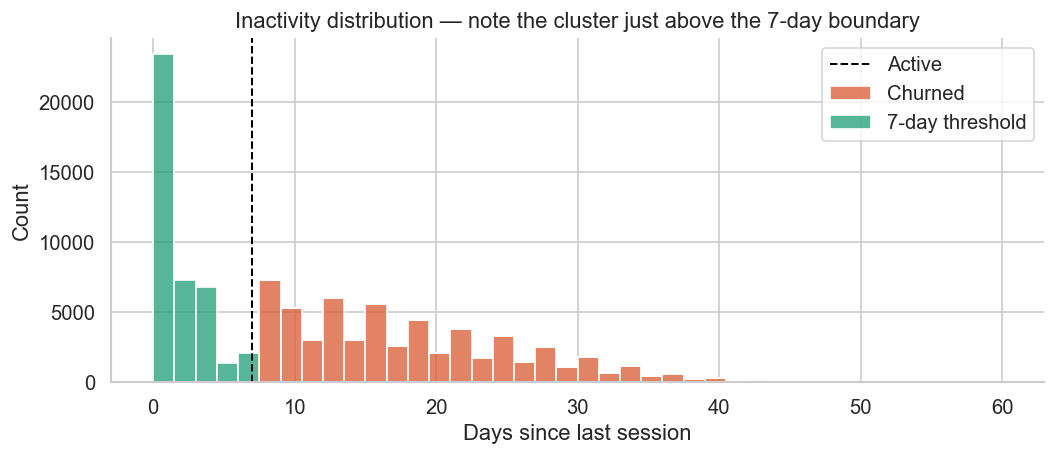

Overall churn rate: 59.0%
Total players:      100,000


In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(data=df, x="days_since_last_session", hue="churned",
             bins=40, multiple="stack", palette=PALETTE, hue_order=[0, 1], ax=ax)
ax.axvline(7, color="black", linestyle="--", linewidth=1.2)
ax.legend(labels=["Active", "Churned", "7-day threshold"])
ax.set_xlabel("Days since last session")
ax.set_title("Inactivity distribution — note the cluster just above the 7-day boundary")
plt.tight_layout(); plt.show()

# ── Churn rate summary ────────────────────────────────────────────────────────
print(f"Overall churn rate: {df['churned'].mean()*100:.1f}%")
print(f"Total players:      {len(df):,}")

### ✏️ First observation

Write 1–2 sentences describing what you see. Do not explain it yet — just describe.

The inactivity distribution shows a large concentration of churned players clustered just above the 7-day threshold, while active players are mostly concentrated at very low days-since-last-session values. There appears to be a sharp drop-off after the 7-day mark, with relatively few players, active or churned, falling in the intermediate range between roughly 3 and 7 days.

---
## 2. Layer 1 — Characterising Churners vs. Actives

**Analytical goal:** understand *what* differs between churned and active players.

> 📖 **Context from Lecture 1:** *"Patterns ≠ Explanation."*
> The patterns you find here describe churn — they do not explain it.
> Your job is to notice when you have described rather than explained.

### 2.1 Summary statistics — implement `describe_churn_split()`

This function reuses the `groupby` pattern from Class 5.
The new twist: we are grouping by a binary outcome (churned vs. active)
and computing both mean and standard deviation per feature.

In [8]:
def describe_churn_split(df, features):
    """
    Compute mean and standard deviation for each feature,
    grouped by churn status. Returns a DataFrame.

    Why: The first thing in any explanatory analysis is understanding
    *what* differs between groups before asking *why* it differs.
    Reuses the groupby pattern from Class 5 — now applied to a binary split.

    Parameters
    ----------
    df       : DataFrame with a 'churn_label' column ('Active' / 'Churned')
    features : list of column names to summarise

    Returns
    -------
    DataFrame with mean and std for each feature, indexed by churn_label
    """
    summary = df.groupby("churn_label")[features].agg(["mean", "std"]).round(2)
    
    return summary

# ── Define features of interest ──────────────────────────────────────────────
FEATURES = [
    "total_sessions",
    "highest_level_reached",
    "avg_session_duration_min",
    "session_duration_trend",
    "days_active_last_7",
    "total_spend_usd",
]

summary = describe_churn_split(df, FEATURES)
print(summary.T.to_string())

churn_label                    Active  Churned
total_sessions           mean   45.09    18.54
                         std    33.33    16.17
highest_level_reached    mean   47.83    22.25
                         std    21.42    12.75
avg_session_duration_min mean   14.47     9.73
                         std     7.99     5.03
session_duration_trend   mean    0.02    -0.29
                         std     0.25     0.38
days_active_last_7       mean    3.35     0.46
                         std     1.68     0.68
total_spend_usd          mean   13.24     0.13
                         std    33.68     0.55


### 2.2 Violin plots — implement `plot_churn_distributions()`

C:\Users\radav\AppData\Local\Temp\ipykernel_25100\1025479573.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="churn_label", y=feat, palette=label_palette,
C:\Users\radav\AppData\Local\Temp\ipykernel_25100\1025479573.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="churn_label", y=feat, palette=label_palette,
C:\Users\radav\AppData\Local\Temp\ipykernel_25100\1025479573.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="churn_label", y=feat, palette=label_palette,
C:\Users\radav\AppData\Lo

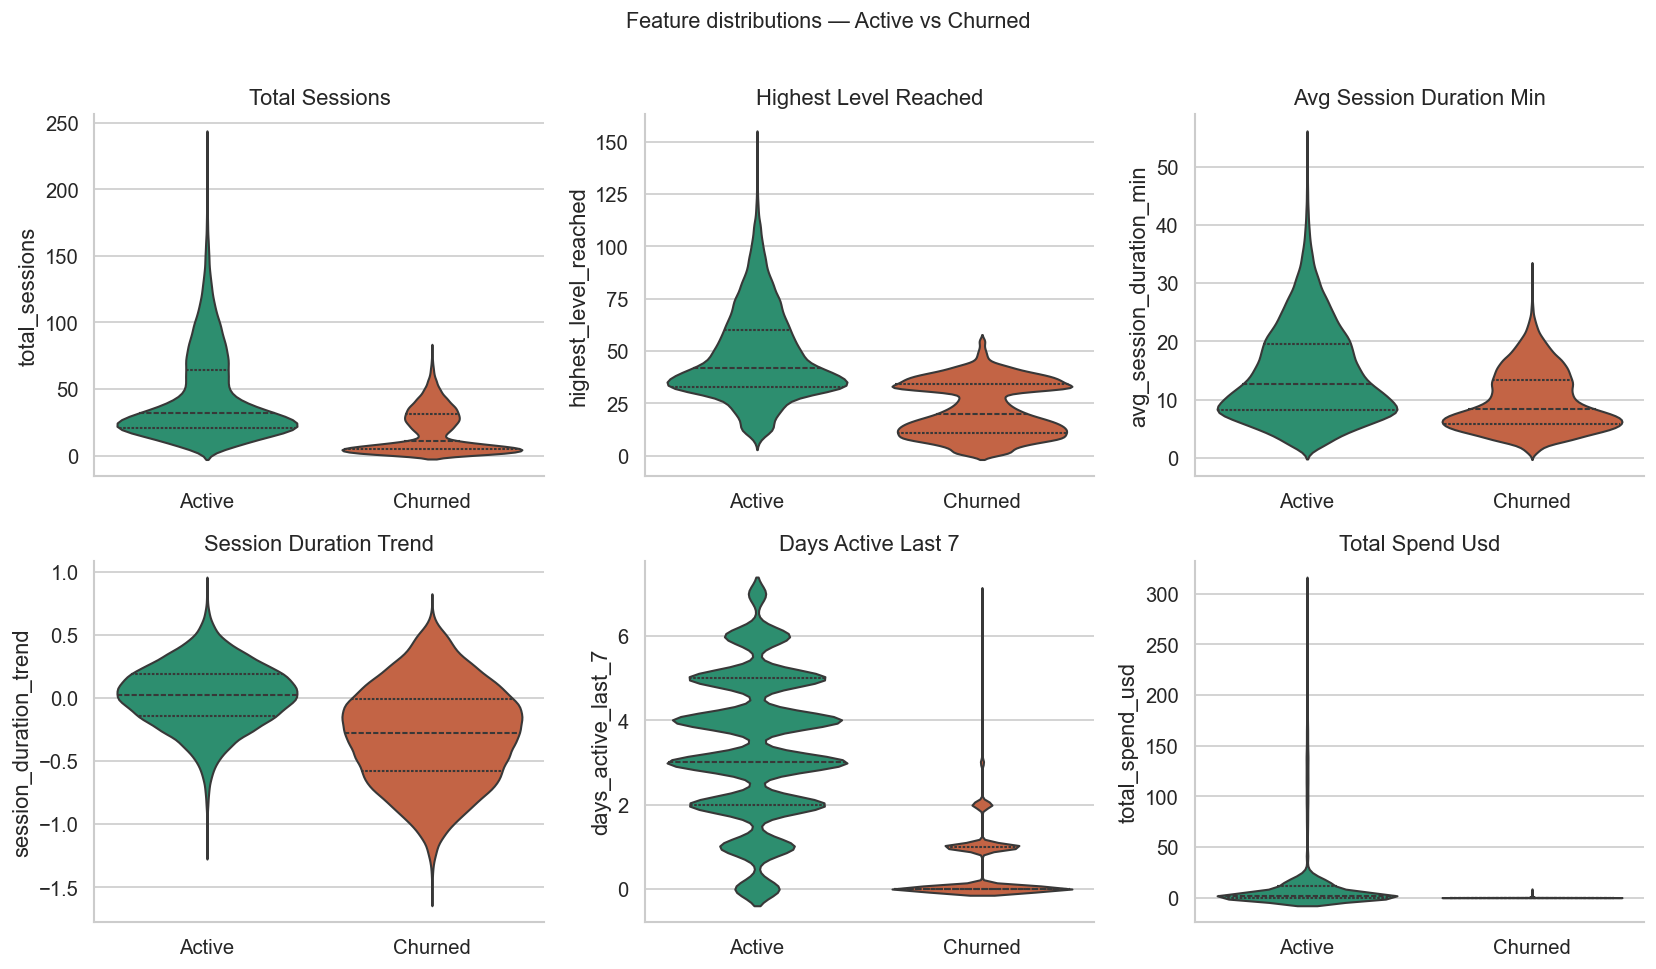

In [ ]:
def plot_churn_distributions(df, features, label_palette):
    """
    Plot violin plots for each feature, split by churn status.
    Why: Means alone (from describe_churn_split) hide the *shape* of the
    distribution. Violin plots show us whether distributions are skewed,
    bimodal, or have heavy tails — things a mean cannot reveal.
    This directly continues the Class 5 visualisation approach.
    Parameters
    ----------
    df            : DataFrame with 'churn_label' column
    features      : list of feature column names to plot
    label_palette : dict mapping label strings to hex colours
                    e.g. {"Active": "#1D9E75", "Churned": "#D85A30"}
    Expected output: a 2x3 grid of violin plots, one per feature.
    """
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flatten()

    for ax, feat in zip(axes, features):
        # YOUR CODE HERE
        # Hint: sns.violinplot(data=..., x=..., y=feat, palette=...,
        #                      order=[...], inner="quartile", ax=ax)
        sns.violinplot(data=df, x="churn_label", y=feat, palette=label_palette,
                       order=["Active", "Churned"], inner="quartile", ax=ax)
        ax.set_xlabel("")
        ax.set_title(feat.replace("_", " ").title())

    plt.suptitle("Feature distributions — Active vs Churned", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

plot_churn_distributions(df, FEATURES, LABEL_PALETTE) 

### ✏️ Layer 1 — First claim

Based on the summary stats and violin plots, complete this sentence:

> *"Players who churn differ from active players in the following ways: ..."*

Then ask yourself: **is this an explanation, or a description?**
Could you have written this claim without looking at the data at all?

Churn players tend to spend less money, have fewer sessions, and reach lower levels than active players. They also have a higher number of days since their last session, which is expected given the definition of churn. However, these observations are descriptive patterns in the data and do not necessarily explain why players churn. They simply indicate that there are differences in behavior between churned and active players, but they do not provide insight into the underlying reasons for those differences.

---
## 3. Layer 2 — Investigating the Difficulty Wall

**Analytical goal:** find *where* in the level progression churn is concentrated.

The game has a designed difficulty spike at **level 35** — the "wall."
Players who reach it typically fail multiple times before passing or giving up.

> **Prediction before running:** do you expect to see elevated churn at level 35?
> Write your prediction here, then test it.

### 3.1 Histogram — implement `plot_level_histogram()`

This extends the Class 5 histogram pattern with one key addition:
a `axvline()` reference line at the wall. Without it, you are just
looking at a distribution — the reference line anchors the question.

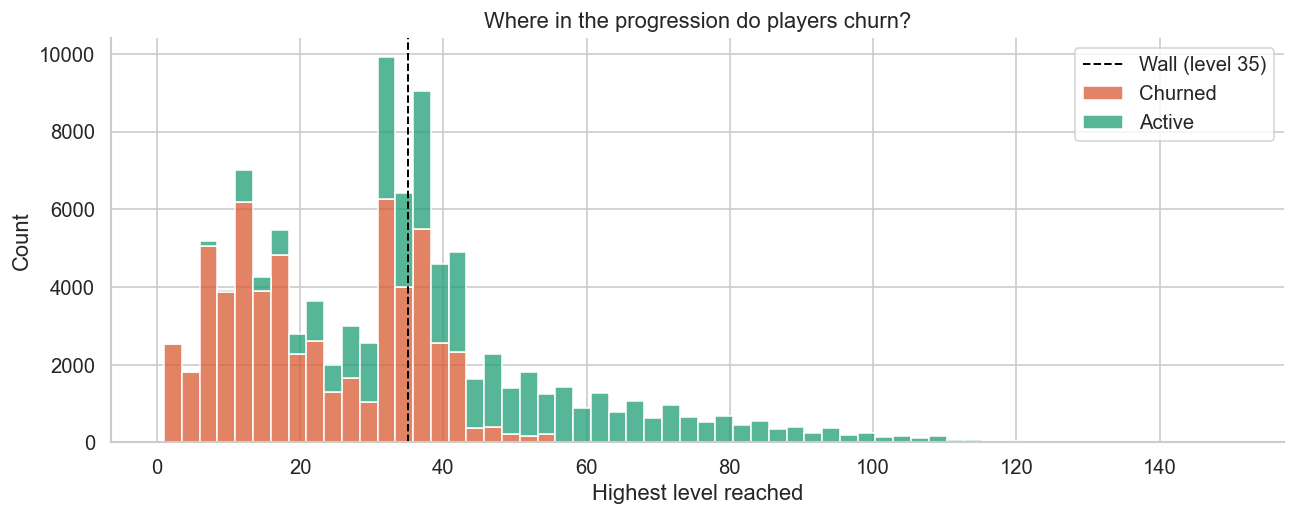

In [12]:
def plot_level_histogram(df, wall_level, palette):
    """
    Plot a stacked histogram of highest_level_reached, coloured by churn status,
    with a vertical reference line at the wall level.
    Why: A histogram shows where in the progression players churn. Adding the
    reference line at the difficulty wall lets us visually test whether
    the wall coincides with a churn spike — Layer 2's core question.
    Parameters
    ----------
    df         : DataFrame with 'highest_level_reached' and 'churned' columns
    wall_level : integer — level at which the difficulty wall sits
    palette    : dict mapping 0/1 to colour hex strings
    Expected output: stacked histogram with black dashed reference line at wall_level.
    """
    fig, ax = plt.subplots(figsize=(11, 4.5))

    # YOUR CODE HERE
    # Step 1: sns.histplot with hue="churned", multiple="stack", hue_order=[0,1]
    sns.histplot(data=df, x="highest_level_reached", hue="churned",
                 multiple="stack", palette=palette, hue_order=[0, 1], bins=60, ax=ax)

    # Step 2: ax.axvline(wall_level, ...) to draw the reference line
    ax.axvline(wall_level, color="black", linestyle="--", linewidth=1.2, label=f"Wall (level {wall_level})")

    # Step 3: set axis labels and title
    ax.legend(labels=[f"Wall (level {wall_level})", "Churned", "Active"])
    ax.set_xlabel("Highest level reached")
    ax.set_title("Where in the progression do players churn?")
    plt.tight_layout()
    plt.show()

plot_level_histogram(df, WALL_LEVEL, PALETTE)

### 3.2 Churn rate by band — implement `compute_churn_by_band()`

            churn_rate  n_players  churn_pct
level_band                                  
1-15          0.944153      24746       94.4
16-30         0.701811      19491       70.2
31-34         0.630538      13092       63.1
35-40         0.595001      16884       59.5
41-60         0.237118      15545       23.7
61+           0.000000      10242        0.0


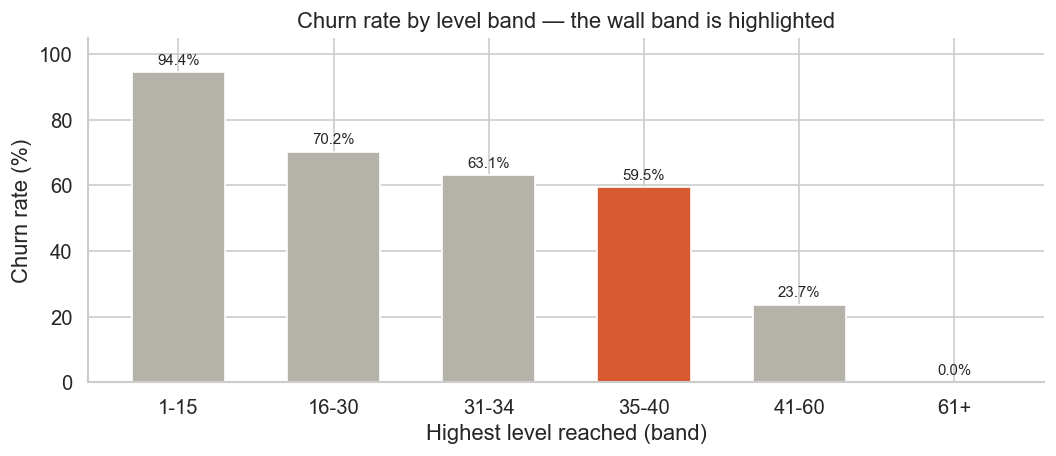

In [14]:
def compute_churn_by_band(df, wall_level):
    """
    Bin players into level bands using pd.cut(), then compute the churn
    rate and player count for each band. Returns a DataFrame.
    Why: The histogram shows *where* players are — but not the churn *rate*
    within each region. A player-dense band can look alarming in a histogram
    but have a low churn rate. This function separates volume from rate.
    pd.cut() is new today — it converts a continuous variable (level) into
    ordered categories (bands). This pattern appears constantly in game analytics.
    Parameters
    ----------
    df         : DataFrame with 'highest_level_reached' and 'churned' columns
    wall_level : integer wall level
    Returns
    -------
    DataFrame indexed by level_band with columns:
        churn_rate (0-1 float), n_players (int), churn_pct (float)
    """
    # Define the band boundaries and labels
    bins   = [0, 15, 30, wall_level - 1, wall_level + 5, 60, 999]
    labels = ["1-15", "16-30", f"31-{wall_level-1}",
              f"{wall_level}-{wall_level+5}", "41-60", "61+"]

    df = df.copy()

    # YOUR CODE HERE — Step 1: create a 'level_band' column using pd.cut()
    # Hint: df["level_band"] = pd.cut(df["highest_level_reached"], bins=bins, labels=labels)
    df["level_band"] = pd.cut(df["highest_level_reached"], bins=bins, labels=labels)

    # YOUR CODE HERE — Step 2: groupby "level_band" and aggregate "churned"
    # compute: churn_rate (mean), n_players (count), churn_pct (rate * 100, rounded to 1dp)
    # Hint: .agg(...).assign(churn_pct=lambda x: ...)
    result = (df.groupby("level_band", observed=True)["churned"]
                .agg(churn_rate="mean", n_players="count")
                .assign(churn_pct=lambda x: (x["churn_rate"] * 100).round(1)))

    return result

band_stats = compute_churn_by_band(df, WALL_LEVEL)
print(band_stats.to_string())

# ── Visualise the rate per band (pre-written — focus is on the function above) ──
fig, ax = plt.subplots(figsize=(9, 4))
colors = [PALETTE[1] if f"{WALL_LEVEL}-{WALL_LEVEL+5}" in str(b) else "#B4B2A9"
          for b in band_stats.index]
bars = ax.bar(band_stats.index, band_stats["churn_pct"],
              color=colors, edgecolor="white", width=0.6)
ax.bar_label(bars, labels=[f"{v}%" for v in band_stats["churn_pct"]],
             padding=3, fontsize=9)
ax.set_ylabel("Churn rate (%)")
ax.set_xlabel("Highest level reached (band)")
ax.set_title("Churn rate by level band — the wall band is highlighted")
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

### ✏️ Layer 2 — Revise your claim

> *"Players leave because..."*

Update your claim to include what you found about the wall.

**Critical question before continuing:** not all wall-hitters churn.
Some players push through. *What is different about the players who stay?*
Write your prediction — then Layer 3 will test it.

Players may leave because they find the difficulty wall at level 35 too challenging or frustrating, leading to a spike in churn around that point. However, not all players who reach the wall churn; some may have higher skill levels, more perseverance, or better support systems (e.g., friends who help them through) that enable them to push through the challenge. Therefore, while the wall may be a significant factor in player churn, it is likely not the sole reason, and other factors such as player motivation, social connections, and individual differences in gaming experience may also play a role in determining who stays and who leaves.

---
## 4. Layer 3 — Testing the Confound

**Analytical goal:** test whether the wall effect is the same for all players,
or whether it changes depending on player state.

Two splits to run:
1. **Spending status** — did the player ever make an in-app purchase?
2. **Recent activity** — how many of the last 7 days did they play?

### 4.1 Wall split — implement `plot_wall_split()`

This is the core Layer 3 operation. It is written as a *reusable* function
because we will call it twice with different split variables.
The underlying pattern is always the same: **filter → group → compute rate → visualise.**

Churn rate at wall — split by spender:
             churn_pct      n
Non-spender       79.1  22058
Spender            6.2   6924


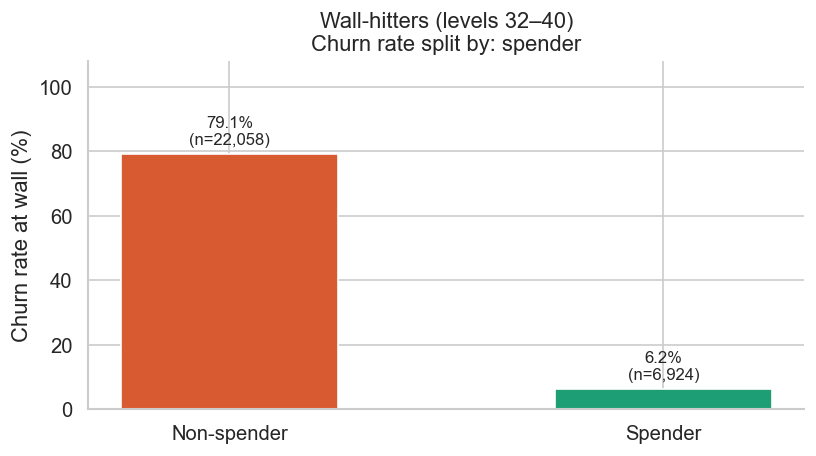

,churn_rate,n,churn_pct
Non-spender,0.790915,22058,79.1
Spender,0.061670,6924,6.2


In [15]:
def plot_wall_split(df, wall_level, split_col, split_labels, palette_override=None):
    """
    For players who hit the wall (levels wall-3 to wall+5), compute and
    plot the churn rate split by a given binary or categorical column.
    Why: This is the core Layer 3 operation — testing whether the wall
    effect is uniform across all players, or whether it depends on player
    state. Making this a reusable function is intentional: we will call
    it twice (spend, then activity). The pattern is always the same:
    filter → group → compute rate → visualise.
    Parameters
    ----------
    df              : full DataFrame
    wall_level      : integer wall level
    split_col       : column name to split on (e.g. "spender", "activity_group")
    split_labels    : list of human-readable labels for the split values
    palette_override: optional list of colour hex strings
    Returns
    -------
    DataFrame with churn_pct and n for each group
    """
    # YOUR CODE HERE — Step 1: filter to wall-hitters
    # Hint: df[df["highest_level_reached"].between(wall_level - 3, wall_level + 5)]
    wall_df = df[df["highest_level_reached"].between(wall_level - 3, wall_level + 5)]

    # YOUR CODE HERE — Step 2: groupby split_col, aggregate churned
    # compute churn_rate (mean), n (count), churn_pct (rate * 100, rounded)
    result = (wall_df.groupby(split_col)["churned"]
                     .agg(churn_rate="mean", n="count")
                     .assign(churn_pct=lambda x: (x["churn_rate"] * 100).round(1)))

    result.index = split_labels
    print(f"Churn rate at wall — split by {split_col}:")
    print(result[["churn_pct", "n"]].to_string())

    # ── Visualisation (pre-written once you have result) ─────────────────────
    colors = palette_override or [PALETTE[1], PALETTE[0]]
    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(result.index, result["churn_pct"],
                  color=colors[:len(result)], edgecolor="white", width=0.5)
    ax.bar_label(bars,
                 labels=[f"{v}%\n(n={n:,})" for v, n in
                         zip(result["churn_pct"], result["n"])],
                 padding=4, fontsize=10)
    ax.set_ylabel("Churn rate at wall (%)")
    ax.set_title(f"Wall-hitters (levels {wall_level-3}–{wall_level+5})\n"
                 f"Churn rate split by: {split_col}")
    ax.set_ylim(0, 108)
    plt.tight_layout()
    plt.show()
    return result

# ── Split 1: spending status ──────────────────────────────────────────────────
df["spender"] = (df["iap_count"] > 0).astype(int)
plot_wall_split(df, WALL_LEVEL,
                split_col="spender",
                split_labels=["Non-spender", "Spender"])

### 4.2 Activity split — reuse `plot_wall_split()`

Churn rate at wall — split by activity_group:
             churn_pct      n
Low (0-1d)        90.7  19347
Mid (2-3d)         5.6   5480
High (4-7d)        0.4   4155


C:\Users\radav\AppData\Local\Temp\ipykernel_25100\1449039557.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = (wall_df.groupby(split_col)["churned"]


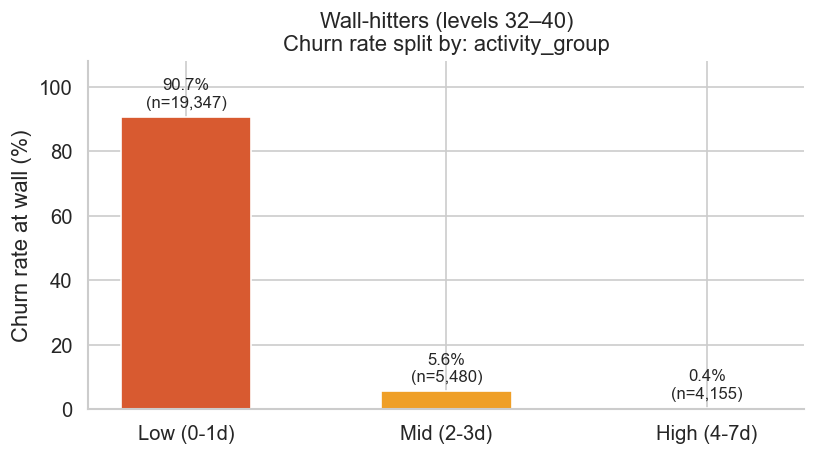

,churn_rate,n,churn_pct
Low (0-1d),0.907221,19347,90.7
Mid (2-3d),0.055657,5480,5.6
High (4-7d),0.003851,4155,0.4


In [16]:
# ── Split 2: recent activity level ───────────────────────────────────────────
# YOUR CODE HERE — create an 'activity_group' column using pd.cut()
# Bins: [-1, 1, 3, 7]   Labels: ["Low (0-1d)", "Mid (2-3d)", "High (4-7d)"]
# Then call plot_wall_split() with the new column.
# This is the same reusable function you implemented above — same pattern,
# different variable. Notice how writing a general function pays off here.
# df["activity_group"] = pd.cut(...)
# plot_wall_split(df, WALL_LEVEL,
#                 split_col="activity_group",
#                 split_labels=[...],
#                 palette_override=["#D85A30", "#EF9F27", "#1D9E75"])

df["activity_group"] = pd.cut(df["days_active_last_7"],
                               bins=[-1, 1, 3, 7],
                               labels=["Low (0-1d)", "Mid (2-3d)", "High (4-7d)"])

plot_wall_split(df, WALL_LEVEL,
                split_col="activity_group",
                split_labels=["Low (0-1d)", "Mid (2-3d)", "High (4-7d)"],
                palette_override=["#D85A30", "#EF9F27", "#1D9E75"])

### ✏️ After both splits — revise your claim

Before moving to the correlation heatmap, update your claim:

> *"The wall causes churn primarily for... because..."*

Is your claim now more or less confident than the Layer 2 version?
What new questions does it raise?

### 4.3 Correlation heatmap — implement `plot_correlation_heatmap()`

> **Before running:** look at the column list in `NUMERIC_COLS` below.
> Which feature do you expect to have the *highest* correlation with `churned`?
> Write your prediction, then check it.

Correlation with 'churned' (sorted):
days_active_last_7           -0.766
highest_level_reached        -0.598
friends_connected            -0.526
levels_failed_total          -0.477
total_sessions               -0.468
session_duration_trend       -0.408
boosters_used                -0.385
avg_session_duration_min     -0.342
iap_count                    -0.333
total_spend_usd              -0.286
notification_response_rate   -0.207
avg_sessions_per_day         -0.187
level_win_rate                0.064
days_since_last_session       0.785


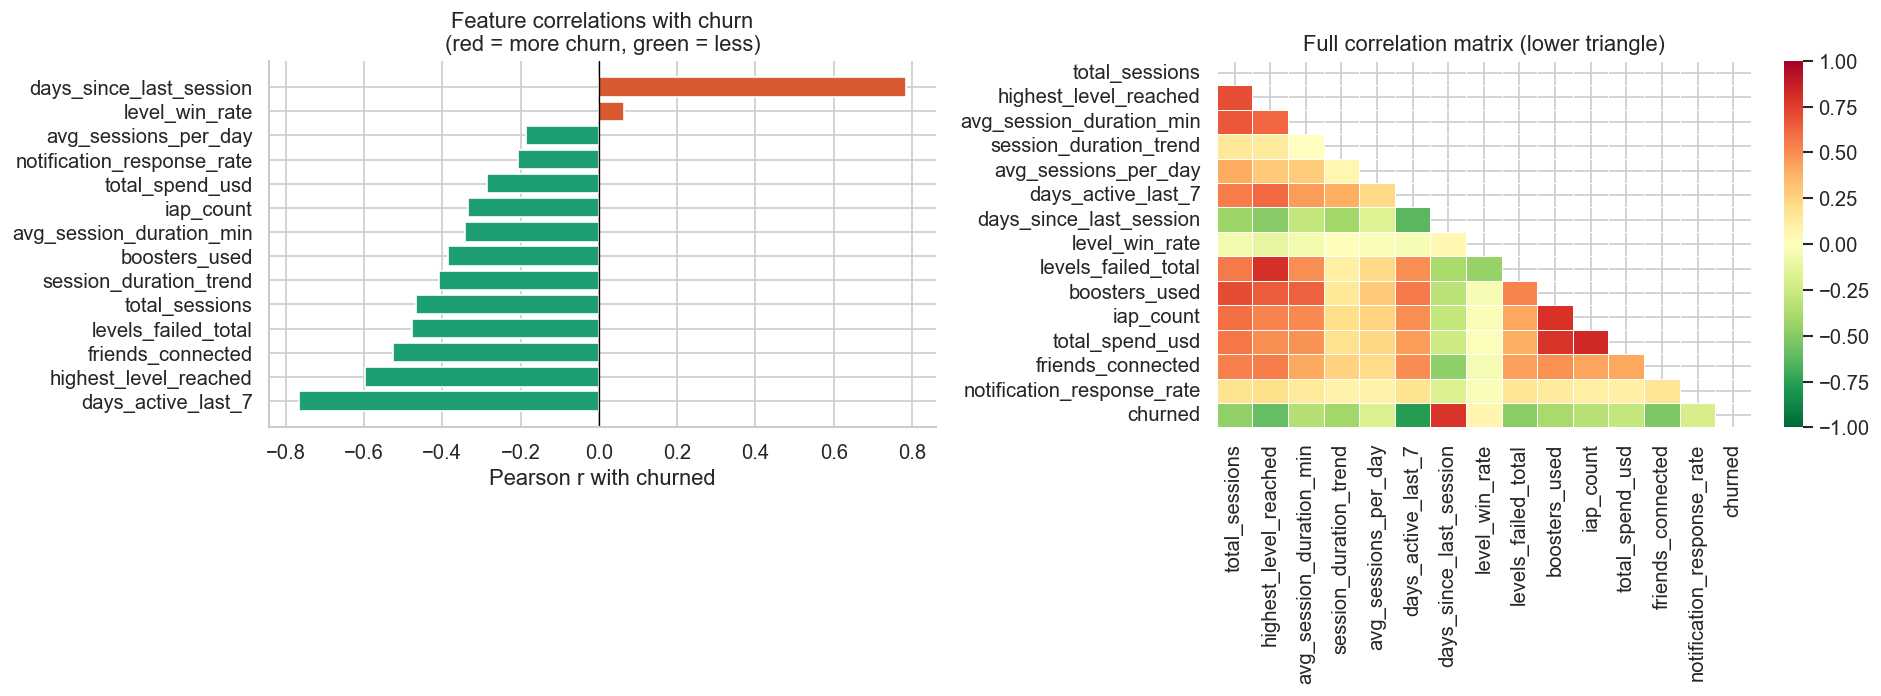

In [17]:
def plot_correlation_heatmap(df, numeric_cols, target="churned"):
    """
    Compute the Pearson correlation matrix for the given columns,
    then display:
      (1) a bar chart of correlations with the target column (sorted)
      (2) a lower-triangle heatmap of the full correlation matrix
    New method: df.corr()
    Key framing: correlation ≠ causation. A feature can correlate with churn
    because it causes it, because churn causes it, or because a third variable
    drives both. The heatmap raises questions — it does not answer them.
    Parameters
    ----------
    df           : DataFrame
    numeric_cols : list of numeric column names to include (must contain target)
    target       : column to rank correlations against (default: "churned")
    Expected output: two side-by-side plots — ranked bar chart and heatmap.
    """
    # YOUR CODE HERE — Step 1: compute correlation matrix
    # Hint: df[numeric_cols].corr()
    corr_matrix = df[numeric_cols].corr()

    # YOUR CODE HERE — Step 2: extract and sort correlations with the target
    # Drop the target from its own row, then sort_values()
    churn_corr = corr_matrix[target].drop(target).sort_values()

    print(f"Correlation with '{target}' (sorted):")
    print(churn_corr.round(3).to_string())

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # ── Left: ranked bar chart (implement this) ───────────────────────────────
    # Color positive values coral (#D85A30), negative values teal (#1D9E75)
    bar_colors = ["#D85A30" if v > 0 else "#1D9E75" for v in churn_corr.values]

    # YOUR CODE HERE — axes[0].barh(...)
    axes[0].barh(churn_corr.index, churn_corr.values, color=bar_colors)
    axes[0].axvline(0, color="black", linewidth=0.8)
    axes[0].set_xlabel("Pearson r with churned")
    axes[0].set_title("Feature correlations with churn\n"
                      "(red = more churn, green = less)")

    # ── Right: lower-triangle heatmap (pre-written once you have corr_matrix) ─
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, cmap="RdYlGn_r",
                center=0, vmin=-1, vmax=1,
                annot=False, linewidths=0.4, ax=axes[1])
    axes[1].set_title("Full correlation matrix (lower triangle)")
    plt.tight_layout()
    plt.show()

NUMERIC_COLS = [
    "total_sessions", "highest_level_reached", "avg_session_duration_min",
    "session_duration_trend", "avg_sessions_per_day", "days_active_last_7",
    "days_since_last_session", "level_win_rate", "levels_failed_total",
    "boosters_used", "iap_count", "total_spend_usd",
    "friends_connected", "notification_response_rate", "churned"
]
plot_correlation_heatmap(df, NUMERIC_COLS)

### 4.4 Session duration trend — the temporal signal

`session_duration_trend` is different from every other feature in this dataset.
It is not a snapshot of current state — it is a *slope*.

A value of **-0.5** means: over the player's last N sessions, their average
session duration was shrinking by half a minute per session.
A value of **+0.1** means: their sessions were growing slightly longer.

> **Question before running:** if players who churn at the wall had a declining
> trend *before* reaching the wall, what would that imply about the cause of churn?

### Implement `analyse_session_trend()`

This function introduces the T-test — a statistical test that answers:
*"Is the difference in means between two groups larger than we would expect by chance?"*

C:\Users\radav\AppData\Local\Temp\ipykernel_25100\3046637232.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=wall_df, x="churn_label", y="session_duration_trend",


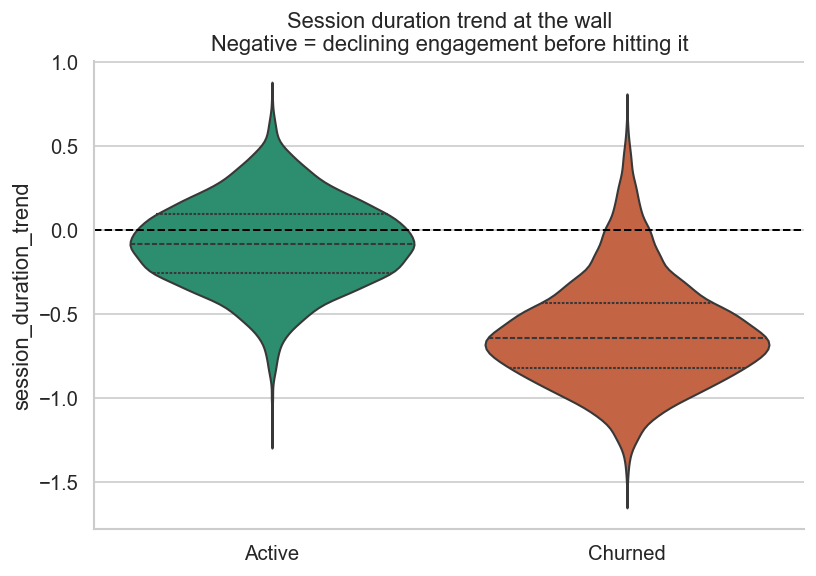

Independent-samples T-test: session_duration_trend
  Mean (churned) : -0.603
  Mean (active)  : -0.082
  t = -144.682   |   p = 0.00e+00


In [19]:
def analyse_session_trend(df, wall_level):
    """
    For wall-hitters, compare session_duration_trend between churned and
    active players using a violin plot and an independent-samples T-test.
    Why: session_duration_trend is a *temporal* feature — a slope, not a
    snapshot. If churned players had a declining trend before hitting the wall,
    disengagement preceded the wall encounter. The wall revealed it; it did
    not cause it.
    New method: scipy.stats.ttest_ind(group_a, group_b)
    The T-test answers: is the difference in means between two groups larger
    than we would expect by chance? p < 0.05 = statistically significant.
    Parameters
    ----------
    df         : full DataFrame (will be filtered to wall-hitters inside)
    wall_level : integer wall level
    """
    wall_df = df[df["highest_level_reached"].between(wall_level - 3, wall_level + 5)].copy()
    wall_df["churn_label"] = wall_df["churned"].map(CHURN_LABEL)

    # ── Violin plot (implement this) ──────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 5))

    # YOUR CODE HERE — sns.violinplot of session_duration_trend split by churn_label
    # Add ax.axhline(0, ...) as a reference line at zero trend
    sns.violinplot(data=wall_df, x="churn_label", y="session_duration_trend",
                   palette=LABEL_PALETTE, order=["Active", "Churned"],
                   inner="quartile", ax=ax)
    ax.axhline(0, color="black", linestyle="--", linewidth=1.2)

    ax.set_xlabel("")
    ax.set_title("Session duration trend at the wall\n"
                 "Negative = declining engagement before hitting it")
    plt.tight_layout()
    plt.show()

    # ── T-test (implement this) ───────────────────────────────────────────────
    # Step 1: extract the trend values for each group
    churned_trend = wall_df[wall_df["churned"] == 1]["session_duration_trend"]
    active_trend  = wall_df[wall_df["churned"] == 0]["session_duration_trend"]

    # YOUR CODE HERE — call stats.ttest_ind(churned_trend, active_trend)
    # and store the result as t_stat, p_val
    t_stat, p_val = stats.ttest_ind(churned_trend, active_trend)

    print("Independent-samples T-test: session_duration_trend")
    print(f"  Mean (churned) : {churned_trend.mean():.3f}")
    print(f"  Mean (active)  : {active_trend.mean():.3f}")
    print(f"  t = {t_stat:.3f}   |   p = {p_val:.2e}")

analyse_session_trend(df, WALL_LEVEL)

---
## 5. Final Claim

Write your final explanatory claim. It must include:

1. **The mechanism** — what causes churn (not just what correlates with it)
2. **Evidence** — at least one specific finding (a number, a test result, a chart)
3. **A complication** — one finding that limits or challenges your claim
4. **What remains unknown** — what additional data would you need?

> *Your final claim here...*

---

### Reflection questions

> 1. At what point did your analysis shift from *describing* churn to *explaining* it?
>
> 2. If you were a game designer reading your claim, what would you change?
>    What would you deliberately *not* change?
>
> 3. The churn label is defined as "inactive for 7 days." Is this a good definition?
>    What assumptions does it carry? What would change if you used 14 days?

---

**Submission — push your Git repository with:**
- This notebook with all functions implemented and all cells run
- Your final claim written above
- At least one visualisation per section

---
## 6. Going Further *(optional)*

**6.1 Combined split**
Create a 2×2 split: `spender` × activity group (high vs. low).
Which combination has the lowest churn rate at the wall? The highest?

**6.2 Spending typology**
Non-spenders / light spenders (1–2 iap) / heavy spenders (3+).
How does churn rate vary across the whole dataset — not just at the wall?

**6.3 Notification pathway**
Players with `notifications_enabled = 0` have no push notification return pathway.
Does this interact with churn at the wall?

**6.4 Trend over progression**
Plot `session_duration_trend` as a boxplot across `level_band` groups.
At which band does the decline begin? Does this change your claim about the wall?

In [ ]:
# Your exploratory code here
